# Italian power prices: does the weather move the market - and can a forecast see it coming?

A 2026 study (Guerzoni, Riso & Zoia, *NAJEF*) found that extreme weather is the main driver
of Italian electricity-price volatility, using a GARCH-MIDAS model on *observed* weather.
Observed weather explains volatility after it has happened; a hedger needs it before.
This notebook builds the three-stage version:

1. **weather → price**: what drives the daily price, and in what shape?
2. **weather → volatility**: GARCH-MIDAS, monthly weather setting the long-run level
3. **forecast → volatility**: how many months ahead does a weather *forecast* still help?

> **Data status.** The pipeline runs on a *placeholder* in the shape of the real series
> (GME prices, ERA5 weather, TTF gas, Terna load), with every relationship planted at a
> known strength. Each stage is therefore a test: does it recover the planted answer?
> Figures are stamped until the real series replace it.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import shap

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
import power as pw

df, extreme = pw.placeholder()
stamp = figstyle.watermark
months = df.index.to_period('M')
order = {m: i for i, m in enumerate(sorted(months.unique()))}
month_idx = np.array([order[m] for m in months])
print(f"{len(df)} days, {df.index[0].date()} to {df.index[-1].date()}")

C:\Users\kevin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3653 days, 2015-01-01 to 2024-12-31


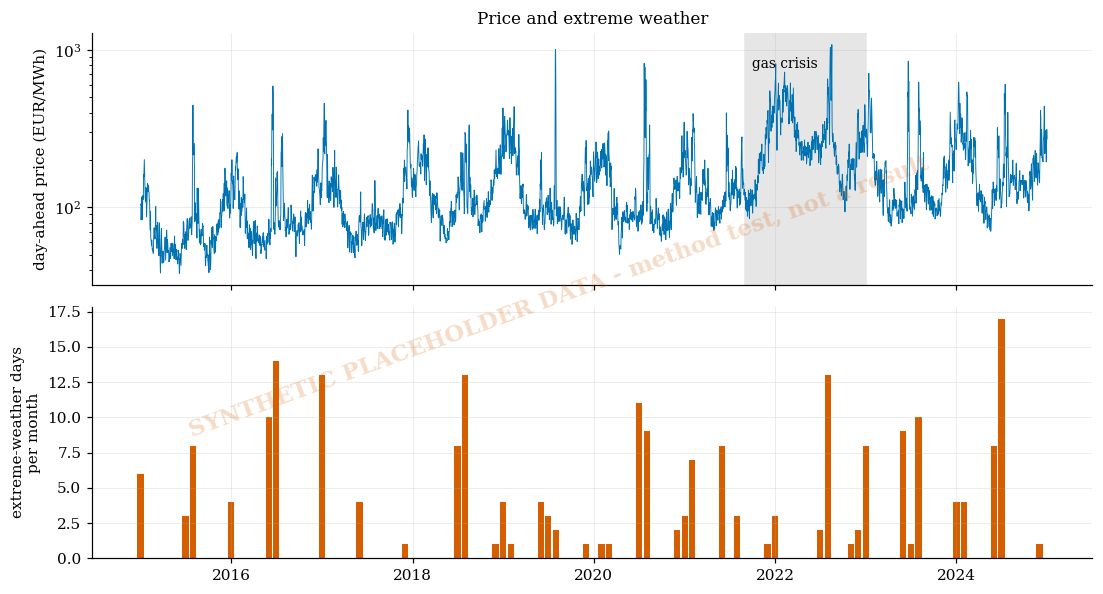

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(df.index, df.price, color=figstyle.PALETTE[0], lw=0.6)
axes[0].set_yscale('log'); axes[0].set_ylabel('day-ahead price (EUR/MWh)')
axes[0].axvspan(pd.Timestamp('2021-09-01'), pd.Timestamp('2022-12-31'), color='0.9', zorder=0)
axes[0].text(pd.Timestamp('2021-10-01'), axes[0].get_ylim()[1] * 0.6, 'gas crisis', fontsize=9)
axes[1].bar(extreme.index.to_timestamp(), extreme.values, width=25, color=figstyle.PALETTE[1])
axes[1].set_ylabel('extreme-weather days\nper month')
axes[0].set_title('Price and extreme weather')
fig.tight_layout(); stamp(fig)
figstyle.save(fig, 'figures/fig1_price_and_weather')
plt.show()

## Stage 1 - what drives the price?

Gas plants usually set the Italian price, so gas comes first. A tree model cannot
extrapolate: one that never saw 2022 gas prices cannot predict 2022 power prices. So the
model learns `log(price / gas)` - what weather, demand and renewables add on top - with
strictly time-ordered validation (train on the past, test on the next year, never the
other way).

In [3]:
xgb = lambda: XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05)
rows = []
for target in ['log_price', 'log_price_over_gas']:
    for name, factory in [('linear', LinearRegression), ('XGBoost', xgb)]:
        _, rmse = pw.time_ordered_cv(df, factory, target=target)
        rows.append(dict(target=target, model=name, rmse=rmse))
pd.DataFrame(rows).pivot(index='model', columns='target', values='rmse').round(3)

target,log_price,log_price_over_gas
model,,
XGBoost,0.245,0.216
linear,0.187,0.187


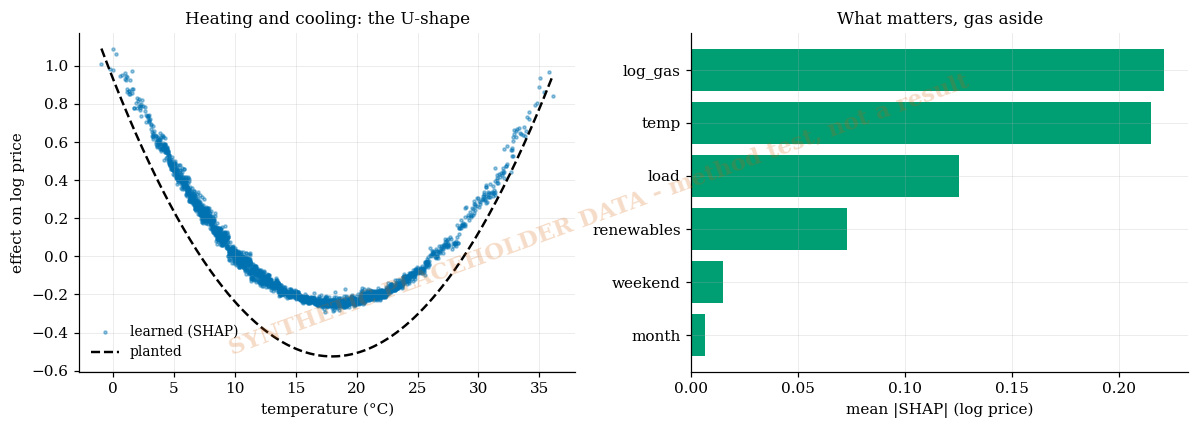

In [4]:
#SHAP: the shape of each driver's effect, as XGBoost learned it
X = df[pw.FEATURES]
y = np.log(df.price) - df.log_gas
model = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05).fit(X, y)
sv = shap.TreeExplainer(model).shap_values(X.sample(3000, random_state=0))
Xs = X.sample(3000, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(Xs.temp, sv[:, pw.FEATURES.index('temp')], s=4, alpha=0.4, color=figstyle.PALETTE[0], label='learned (SHAP)')
t = np.linspace(Xs.temp.min(), Xs.temp.max(), 200)
planted = pw.TRUE['heat_curve'] * (t - 18) ** 2
axes[0].plot(t, planted - planted.mean() + sv[:, 0].mean(), 'k--', label='planted')
axes[0].set_xlabel('temperature (°C)'); axes[0].set_ylabel('effect on log price')
axes[0].set_title('Heating and cooling: the U-shape'); axes[0].legend()
importance = np.abs(sv).mean(0)
o = np.argsort(importance)
axes[1].barh(np.array(pw.FEATURES)[o], importance[o], color=figstyle.PALETTE[2])
axes[1].set_xlabel('mean |SHAP| (log price)'); axes[1].set_title('What matters, gas aside')
fig.tight_layout(); stamp(fig)
figstyle.save(fig, 'figures/fig2_shap')
plt.show()

**Gas has to come out first - and on this data the straight line still wins.** Modelling
the raw price, XGBoost cannot extrapolate to crisis-level gas prices it never saw;
modelling price relative to gas narrows the gap but does not close it, because the planted
relationships are nearly linear and most of the error is a persistent unexplained
component neither model can see. What XGBoost does give is the *shape*: SHAP recovers the
planted U-curve of heating and cooling demand. On real prices - heatwave thresholds,
interactions with renewables - whether the trees earn their keep is the open question.

## Stage 2 - what drives the volatility?

GARCH-MIDAS splits volatility into a fast part (bad days cluster) and a slow monthly level
driven by the number of extreme-weather days in the previous six months, with the weights
on past months following a one-parameter curve. Fitted to ten independent placeholder
datasets, the estimator scatters around the planted values - unbiased, but not precise:
ten years of monthly data pin the weather effect down only loosely.

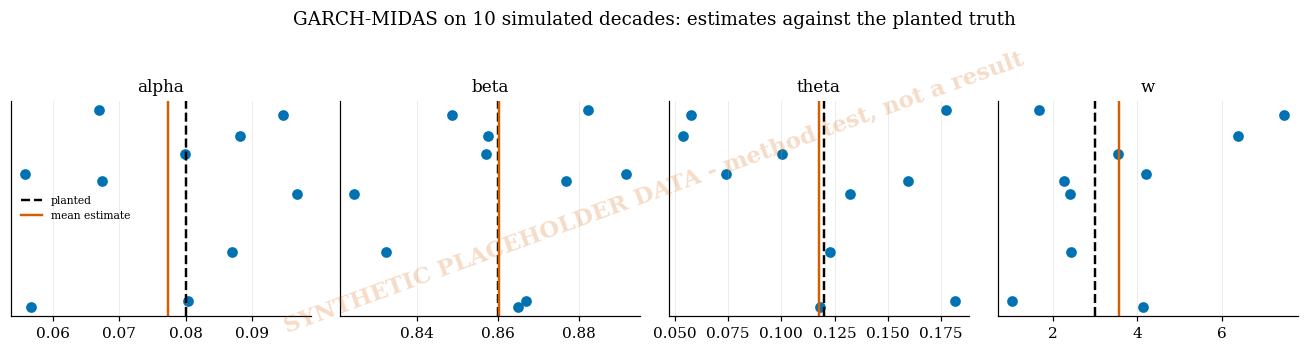

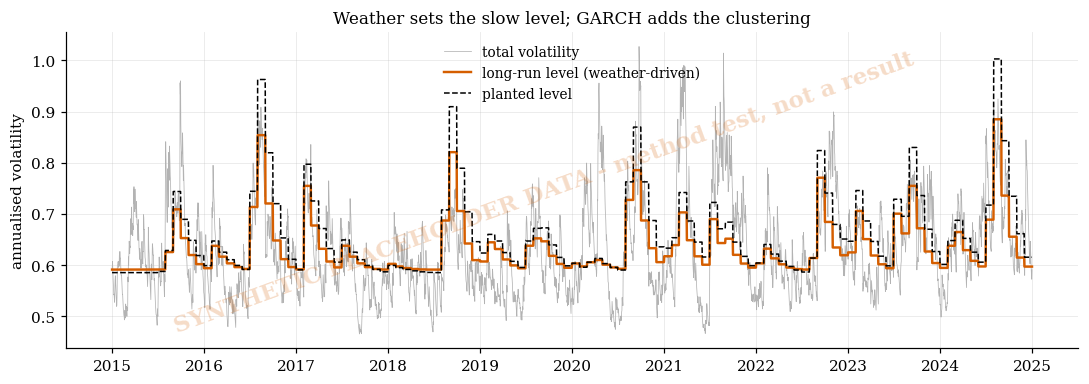

In [5]:
rec = pd.read_csv('results/midas_recovery.csv')
truth = {'alpha': pw.TRUE['garch_alpha'], 'beta': pw.TRUE['garch_beta'], 'theta': pw.TRUE['midas_theta'], 'w': pw.TRUE['midas_w']}
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (k, v) in zip(axes, truth.items()):
    ax.scatter(rec[k], np.random.default_rng(0).uniform(-0.2, 0.2, len(rec)), color=figstyle.PALETTE[0])
    ax.axvline(v, color='k', ls='--', label='planted')
    ax.axvline(rec[k].mean(), color=figstyle.PALETTE[1], label='mean estimate')
    ax.set_yticks([]); ax.set_title(k)
axes[0].legend(fontsize=7)
fig.suptitle('GARCH-MIDAS on 10 simulated decades: estimates against the planted truth', y=1.05)
fig.tight_layout(); stamp(fig)
figstyle.save(fig, 'figures/fig3_midas_recovery')
plt.show()

params, _ = pw.fit_garch_midas(df.shock.values, month_idx, extreme.values.astype(float))
var, tau = pw.garch_midas_variance(params, df.shock.values, month_idx, extreme.values.astype(float))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(df.index, np.sqrt(var * 252), color='0.7', lw=0.5, label='total volatility')
ax.plot(df.index, np.sqrt(tau * 252), color=figstyle.PALETTE[1], lw=1.6, label='long-run level (weather-driven)')
ax.plot(df.index, np.sqrt(df.true_tau * 252), 'k--', lw=1, label='planted level')
ax.set_ylabel('annualised volatility'); ax.legend(); ax.set_title('Weather sets the slow level; GARCH adds the clustering')
fig.tight_layout(); stamp(fig)
figstyle.save(fig, 'figures/fig4_volatility_components')
plt.show()

## Stage 3 - one step beyond the paper: forecasts instead of hindsight

Replace observed extreme-weather counts with a *forecast* made 1 to 6 months ahead (on real
data: ECMWF's SEAS5 seasonal forecast). Fit on the first seven years, score on the last
three, out of sample, with QLIKE - the standard loss for volatility forecasts - against a
plain GARCH with no weather at all. In the placeholder, forecast error grows with lead
time at a planted rate, so the horizon where the advantage vanishes is known in advance.

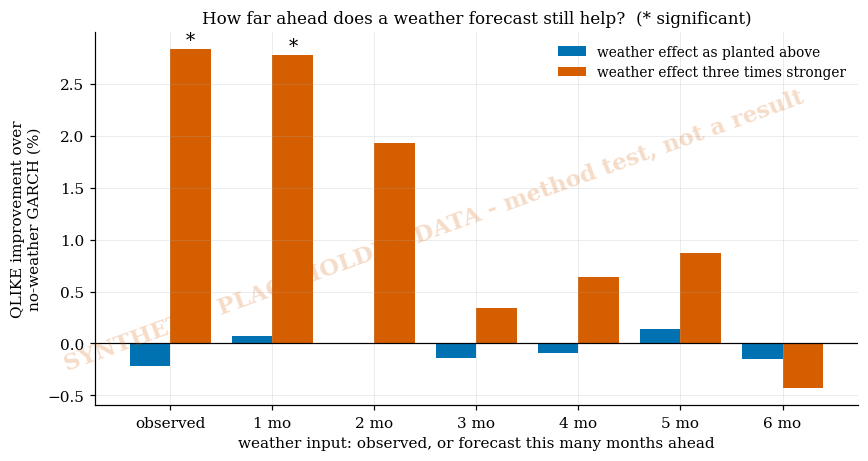

weather effect as planted above
   observed           improvement -0.2%   DM +0.44
   1-month forecast   improvement +0.1%   DM -0.19
   2-month forecast   improvement -0.0%   DM +0.01
   3-month forecast   improvement -0.1%   DM +0.54
   4-month forecast   improvement -0.1%   DM +0.47
   5-month forecast   improvement +0.1%   DM -0.51
   6-month forecast   improvement -0.2%   DM +1.09
weather effect three times stronger
   observed           improvement +2.8%   DM -2.05
   1-month forecast   improvement +2.8%   DM -2.14
   2-month forecast   improvement +1.9%   DM -1.70
   3-month forecast   improvement +0.3%   DM -0.42
   4-month forecast   improvement +0.6%   DM -1.27
   5-month forecast   improvement +0.9%   DM -1.84
   6-month forecast   improvement -0.4%   DM +1.56


In [6]:
def forecast_skill(theta, seed=5):
    d, ex = pw.placeholder(midas_theta=theta)
    r = d.shock.values
    realised = r ** 2
    split = month_idx < order[pd.Period('2022-01', 'M')]
    null = pw.fit_garch11(r[split])
    h_null = pw.garch11_variance(null, r)
    loss_null = pw.qlike(realised[~split], h_null[~split])
    lb = realised[~split] / h_null[~split] - np.log(realised[~split] / h_null[~split]) - 1
    rng = np.random.default_rng(seed)
    gain, dm = [], []
    for lead in range(7):
        sd = pw.TRUE['forecast_noise_by_lead'][lead]
        X_fc = np.maximum(ex.values + rng.normal(0, sd, len(ex)), 0) if lead else ex.values.astype(float)
        p, _ = pw.fit_garch_midas(r[split], month_idx[split], X_fc)
        v, _ = pw.garch_midas_variance(p, r, month_idx, X_fc)
        gain.append(1 - pw.qlike(realised[~split], v[~split]) / loss_null)
        la = realised[~split] / v[~split] - np.log(realised[~split] / v[~split]) - 1
        dm.append(pw.diebold_mariano(la, lb))
    return np.array(gain), np.array(dm)

effects = {'weather effect as planted above': pw.TRUE['midas_theta'], 'weather effect three times stronger': 0.35}
skill = {label: forecast_skill(theta) for label, theta in effects.items()}

leads = np.arange(7)
fig, ax = plt.subplots(figsize=(8, 4.3))
for k, ((label, (gain, dm)), colour) in enumerate(zip(skill.items(), [figstyle.PALETTE[0], figstyle.PALETTE[1]])):
    bars = ax.bar(leads + (k - 0.5) * 0.4, gain * 100, 0.4, color=colour, label=label)
    for b, d in zip(bars, dm):
        if d < -1.96:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), '*', ha='center', va='bottom', fontsize=12)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(leads); ax.set_xticklabels(['observed'] + [f'{l} mo' for l in leads[1:]])
ax.set_xlabel('weather input: observed, or forecast this many months ahead')
ax.set_ylabel('QLIKE improvement over\nno-weather GARCH (%)')
ax.set_title('How far ahead does a weather forecast still help?  (* significant)')
ax.legend()
fig.tight_layout(); stamp(fig)
figstyle.save(fig, 'figures/hero')
plt.show()
for label, (gain, dm) in skill.items():
    print(label)
    for lead, g, d in zip(leads, gain, dm):
        print(f"   {'observed' if lead == 0 else f'{lead}-month forecast':18s} improvement {g:+.1%}   DM {d:+.2f}")

**Detecting the effect is the hard part.** At the strength planted in Stage 2, even
*observed* weather does not measurably beat a weather-blind GARCH over three years of
out-of-sample data: daily squared returns are a very noisy yardstick, and a modest
weather effect drowns in them. Make the effect three times stronger and the machinery
finds it - and finds the horizon where the forecast's growing error wipes the advantage
out. So the experiment works, but it needs either a strong effect or a long test period
to say anything; on real prices, a power calculation like this one comes first.

**The machinery works end to end - and says how much data the real question needs.**
SHAP recovers the weather's shape; GARCH-MIDAS recovers the planted weather effect on
average; the forecast experiment finds the horizon when the effect is strong enough to
see. On GME prices with SEAS5 forecasts, that horizon is the result.